# Lab 3: A Conditional Generative Model for Images

**based on lab from MIT course ["Introduction to Flow Matching and Diffusion Models 2026"](https://diffusion.csail.mit.edu/2026/index.html)**

In [1]:
import os
from abc import ABC, abstractmethod
from typing import Optional, List, Type, Tuple
import uuid
import random
import copy

from matplotlib import pyplot as plt
import torch
import torch.nn as nn
from torch.func import vmap, jacrev
from tqdm import tqdm

from torchvision import datasets, transforms
from torchvision.utils import make_grid
from einops import rearrange
from einops.layers.torch import Rearrange
import torch.nn.functional as F

## Part 0: Math

In [2]:
class Sampleable(ABC):
    """
    Distribution which can be sampled from
    """

    @abstractmethod
    def sample(self, num_samples: int) -> torch.Tensor:
        """
        Args:
            - num_samples: the desired number of samples
        Returns:
            - samples: b d
        """
        pass


class LabeledSampleable(ABC):
    """
    Distribution which can be sampled from
    """

    @abstractmethod
    def sample(self, num_samples: int) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        """
        Args:
            - num_samples: the desired number of samples
        Returns:
            - samples: b d
            - labels: b
        """
        pass

In [3]:
class IsotropicGaussian(nn.Module, Sampleable):
    """
    Sampleable wrapper around torch.randn
    """

    def __init__(self, shape: List[int], std: float = 1.0):
        """
        shape: shape of sampled data
        """
        super().__init__()
        self.shape = shape
        self.std = std
        # Will automatically be moved when self.to(...) is called...
        self.dummy = nn.Buffer(torch.zeros(1))

    def sample(self, num_samples) -> torch.Tensor:
        return self.std * torch.randn(num_samples, *self.shape).to(self.dummy.device)

In [4]:
class ConditionalProbabilityPath(nn.Module, ABC):
    """
    Abstract base class for conditional probability paths
    """

    def __init__(self, p_simple: Sampleable, p_data: LabeledSampleable):
        super().__init__()
        self.p_simple = p_simple
        self.p_data = p_data

    def sample_marginal_path(self, t: torch.Tensor) -> torch.Tensor:
        """
        Samples from the marginal distribution p_t(x) = p_t(x|z) p(z)
        Args:
            - t: b
        Returns:
            - x: samples from p_t(x), b ... (i.e.,. `b d`, `b c h w`, etc.)
        """
        num_samples = t.shape[0]
        # Sample conditioning variable z ~ p(z)
        z, _ = self.sample_conditioning_variable(num_samples)  # (b ...)
        # Sample conditional probability path x ~ p_t(x|z)
        x = self.sample_conditional_path(z, t)  # (b ...)
        return x

    @abstractmethod
    def sample_conditioning_variable(
        self, num_samples: int
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Samples the conditioning variable z and label y
        Args:
            - num_samples: the number of samples
        Returns:
            - z: b ...
            - y: b
        """
        pass

    @abstractmethod
    def sample_conditional_path(self, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Samples from the conditional distribution p_t(x|z)
        Args:
            - z: conditioning variable b ...
            - t: time b
        Returns:
            - x: samples from p_t(x|z), b ...
        """
        pass

    @abstractmethod
    def conditional_vector_field(
        self, x: torch.Tensor, z: torch.Tensor, t: torch.Tensor
    ) -> torch.Tensor:
        """
        Evaluates the conditional vector field u_t(x|z)
        Args:
            - x: b ...
            - z: b ...
            - t: b
        Returns:
            - conditional_vector_field: conditional vector field b c h w
        """
        pass

    @abstractmethod
    def conditional_score(
        self, x: torch.Tensor, z: torch.Tensor, t: torch.Tensor
    ) -> torch.Tensor:
        """
        Evaluates the conditional score of p_t(x|z)
        Args:
            - x: b ...
            - z: b ...
            - t: b
        Returns:
            - score: b ...
        """
        pass

In [5]:
class Alpha(ABC):
    def __init__(self):
        # Check alpha_t(0) = 0
        assert torch.allclose(
            self(
                torch.zeros(
                    1,
                )
            ),
            torch.zeros(
                1,
            ),
        )
        # Check alpha_1 = 1
        assert torch.allclose(
            self(
                torch.ones(
                    1,
                )
            ),
            torch.ones(
                1,
            ),
        )

    @abstractmethod
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates alpha_t. Should satisfy: self(0.0) = 0.0, self(1.0) = 1.0.
        Args:
            - t: b
        Returns:
            - alpha_t: b
        """
        pass

    def dt(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates d/dt alpha_t.
        Args:
            - t: b
        Returns:
            - d/dt a_t: b
        """
        t = t.unsqueeze(1)
        dt = vmap(jacrev(self))(t)
        return dt.view(-1)


class Beta(ABC):
    def __init__(self):
        # Check beta_0 = 1
        assert torch.allclose(self(torch.zeros(1)), torch.ones(1))
        # Check beta_1 = 0
        assert torch.allclose(self(torch.ones(1)), torch.zeros(1))

    @abstractmethod
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates alpha_t. Should satisfy: self(0.0) = 1.0, self(1.0) = 0.0.
        Args:
            - t: b
        Returns:
            - beta_t: b
        """
        pass

    def dt(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates d/dt beta_t.
        Args:
            - t: b
        Returns:
            - d/dt beta_t: b
        """
        t = t.unsqueeze(1)
        dt = vmap(jacrev(self))(t)
        return dt.view(-1)


class LinearAlpha(Alpha):
    """
    Implements alpha_t = t
    """

    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            - t: b
        Returns:
            - alpha_t: b
        """
        return t

    def dt(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates d/dt alpha_t.
        Args:
            - t: b
        Returns:
            - d/dt alpha_t b
        """
        return torch.ones_like(t)


class LinearBeta(Beta):
    """
    Implements beta_t = 1-t
    """

    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            - t: b
        Returns:
            - beta_t: b
        """
        return 1 - t

    def dt(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates d/dt alpha_t.
        Args:
            - t: b
        Returns:
            - d/dt alpha_t: b
        """
        return -torch.ones_like(t)


class GaussianConditionalProbabilityPath(ConditionalProbabilityPath):
    def __init__(
        self, p_data: Sampleable, p_simple_shape: List[int], alpha: Alpha, beta: Beta
    ):
        p_simple = IsotropicGaussian(shape=p_simple_shape, std=1.0)
        super().__init__(p_simple, p_data)
        self.alpha = alpha
        self.beta = beta
        self.rearrange_scalar = Rearrange(f'b -> b{" 1" * len(p_simple_shape)}')

    def sample_conditioning_variable(self, num_samples: int) -> torch.Tensor:
        """
        Samples the conditioning variable z and label y
        Args:
            - num_samples: the number of samples
        Returns:
            - z: b ...
            - y: b
        """
        return self.p_data.sample(num_samples)

    def sample_conditional_path(self, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Samples from the conditional distribution p_t(x|z)
        Args:
            - z: b ...
            - t: b
        Returns:
            - x: b ...
        """
        alpha_t = self.rearrange_scalar(self.alpha(t))  # (b 1 1 1)
        beta_t = self.rearrange_scalar(self.beta(t))  # (b 1 1 1)
        return alpha_t * z + beta_t * torch.randn_like(z)

    def conditional_vector_field(
        self, x: torch.Tensor, z: torch.Tensor, t: torch.Tensor
    ) -> torch.Tensor:
        """
        Evaluates the conditional vector field u_t(x|z)
        Args:
            - x: b c h w
            - z: b c h w
            - t: b
        Returns:
            - conditional_vector_field: conditional vector field (num_samples, c, h, w)
        """
        alpha_t = self.rearrange_scalar(self.alpha(t))  # b
        beta_t = self.rearrange_scalar(self.beta(t))  # b
        dt_alpha_t = self.rearrange_scalar(self.alpha.dt(t))  # b
        dt_beta_t = self.rearrange_scalar(self.beta.dt(t))  # b

        return (dt_alpha_t - dt_beta_t / beta_t * alpha_t) * z + dt_beta_t / beta_t * x

    def conditional_score(
        self, x: torch.Tensor, z: torch.Tensor, t: torch.Tensor
    ) -> torch.Tensor:
        """
        Evaluates the conditional score of p_t(x|z)
        Args:
            - x: b ...
            - z: b ...
            - t: b
        Returns:
            - conditional_score: b ...
        """
        alpha_t = self.rearrange_scalar(self.alpha(t))
        beta_t = self.rearrange_scalar(self.beta(t))
        return (z * alpha_t - x) / beta_t**2

In [6]:
class ODE(ABC):
    @abstractmethod
    def drift_coefficient(
        self, xt: torch.Tensor, t: torch.Tensor, **kwargs
    ) -> torch.Tensor:
        """
        Returns the drift coefficient of the ODE.
        Args:
            - xt: b ...
            - t: b
        Returns:
            - drift_coefficient: b ...
        """
        pass

In [7]:
class Simulator(ABC):
    @abstractmethod
    def step(self, xt: torch.Tensor, t: torch.Tensor, dt: torch.Tensor, **kwargs):
        """
        Takes one simulation step
        Args:
            - xt: b ...
            - t: b
            - dt: b
        Returns:
            - nxt: b ...
        """
        pass

    @torch.no_grad()
    def simulate(
        self, x: torch.Tensor, ts: torch.Tensor, use_tqdm: bool = True, **kwargs
    ):
        """
        Simulates using the discretization gives by ts
        Args:
            - x_init: b ...
            - ts: b
        Returns:
            - x_final: b ...
        """
        nts = ts.shape[1]
        pbar = tqdm(range(nts - 1)) if use_tqdm else range(nts - 1)
        for t_idx in pbar:
            t = ts[:, t_idx]
            h = ts[:, t_idx + 1] - ts[:, t_idx]
            x = self.step(x, t, h, **kwargs)
        return x

    @torch.no_grad()
    def simulate_with_trajectory(
        self, x: torch.Tensor, ts: torch.Tensor, use_tqdm: bool = True, **kwargs
    ):
        """
        Simulates using the discretization gives by ts
        Args:
            - x: b ...
            - ts: b nt
        Returns:
            - x_traj: b nt ...
        """
        x_traj = [x.clone()]
        nts = ts.shape[1]
        pbar = tqdm(range(nts - 1)) if use_tqdm else range(nts - 1)
        for t_idx in pbar:
            t = ts[:, t_idx]
            h = ts[:, t_idx + 1] - ts[:, t_idx]
            x = self.step(x, t, h, **kwargs)
            x_traj.append(x.clone())
        return torch.stack(x_traj, dim=1)


class EulerSimulator(Simulator):
    def __init__(self, ode: ODE):
        self.ode = ode

    def step(self, xt: torch.Tensor, t: torch.Tensor, h: torch.Tensor, **kwargs):
        h = h.view([-1] + [1] * (len(xt.shape) - 1))
        return xt + self.ode.drift_coefficient(xt, t, **kwargs) * h

## Part 1: Trainer

In [8]:
MiB = 1024**2


def model_size_b(model: nn.Module) -> int:
    """
    Returns model size in bytes. Based on https://discuss.pytorch.org/t/finding-model-size/130275/2
    Args:
    - model: self-explanatory
    Returns:
    - size: model size in bytes
    """
    size = 0
    for param in model.parameters():
        size += param.nelement() * param.element_size()
    for buf in model.buffers():
        size += buf.nelement() * buf.element_size()
    return size


class Trainer(ABC):
    def __init__(self, **kwargs):
        super().__init__()
        self.model = None
        self.opt = None
        self.output_dir = None

    @abstractmethod
    def get_train_loss(self, **kwargs) -> torch.Tensor:
        pass

    def checkpoint(self, step: int, losses: list[float], rng):
        pass

    def get_optimizer(self, lr: float):
        return torch.optim.AdamW(self.model.parameters(), lr=lr, weight_decay=1e-4)

    def random_name(self) -> str:
        adjectives = [
            "autumn",
            "hidden",
            "bitter",
            "misty",
            "silent",
            "empty",
            "dry",
            "dark",
            "summer",
            "icy",
            "delicate",
            "quiet",
            "white",
            "cool",
            "spring",
            "winter",
            "patient",
        ]
        foods = [
            "apple",
            "banana",
            "pear",
            "plum",
            "orange",
            "persimmon",
            "tangerine",
            "durian",
            "jackfruit",
            "jicama",
            "cantaloupe",
            "watermelon",
            "peach",
        ]
        return f"{random.choice(adjectives)}-{random.choice(foods)}-{str(uuid.uuid4())[:8]}"

    def load(self, model, run_name: str, resume_step: int):
        self.output_dir = os.path.join("runs/", run_name)

        self.model = model
        size_b = model_size_b(self.model)
        print(f"Loading model with size: {size_b / MiB:.3f} MiB")

        self.model.load_state_dict(
            torch.load(f"{self.output_dir}/step_{resume_step:06d}_model.pt")
        )
        self.model.eval()

    def train(
        self,
        model: nn.Module,
        num_steps: int,
        lr: float = 1e-3,
        warmup_steps: int = 500,
        ckpt_every: Optional[int] = 500,
        run_name: Optional[str] = None,
        resume_step: int = 0,
        **kwargs,
    ) -> Tuple[List[float], List[int]]:
        """
        Linear warmup from 0 -> lr over `warmup_steps`, then constant lr.
        """
        # Initialize run name and output directory
        run_name = run_name or self.random_name()
        self.output_dir = os.path.join("runs/", run_name)
        if resume_step != 0:
            os.makedirs(self.output_dir, exist_ok=False)
            print("Initialized output directory at: " + self.output_dir)

        # Grab size
        if resume_step != 0:
            self.load(model, run_name, resume_step)
        else:
            self.model = model
            size_b = model_size_b(self.model)
            print(f"Training model with size: {size_b / MiB:.3f} MiB")

        # Initialize optimizer and LR
        self.opt = self.get_optimizer(lr)
        if resume_step != 0:
            opt_state = torch.load(f"{self.output_dir}/step_{resume_step:06d}_opt.pt")
            self.opt.load_state_dict(opt_state)

        self.model.train()

        for pg in self.opt.param_groups:
            pg["lr"] = 0.0

        # Main training loop
        losses: List[float] = []
        steps: List[int] = []

        pbar = tqdm(range(resume_step + 1, resume_step + num_steps + 1))
        for step in pbar:
            # Update LR
            if warmup_steps > 0 and step < warmup_steps:
                cur_lr = lr * float(step + 1) / float(warmup_steps)
            else:
                cur_lr = lr
            for pg in self.opt.param_groups:
                pg["lr"] = cur_lr

            # Forward + backward
            self.opt.zero_grad(set_to_none=True)
            loss = self.get_train_loss(**kwargs)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.opt.step()

            losses.append(float(loss.detach().item()))
            steps.append(step)

            pbar.set_description(
                f"Step {step}, lr={cur_lr:.2e}, loss={loss.item():.4f}"
            )

            # Callback if specified
            if ckpt_every is not None and step % ckpt_every == 0 and step > 0:
                self.model.eval()
                self.checkpoint(step, losses, steps)
                self.model.train()

        self.model.eval()
        return losses, steps

## Part 3: Dataset

In [9]:
class DataSampler(nn.Module, LabeledSampleable):
    """
    Sampleable wrapper for our dataset
    """

    def __init__(self, dataset):
        super().__init__()
        self.dataset = dataset
        # Will automatically be moved when self.to(...) is called...
        self.dummy = nn.Buffer(torch.zeros(1))

    def sample(self, num_samples: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
            - num_samples: the desired number of samples
        Returns:
            - samples: shape (batch_size, c, h, w)
            - labels: shape (batch_size, label_dim)
        """
        if num_samples > len(self.dataset):
            raise ValueError(f"num_samples exceeds dataset size: {len(self.dataset)}")

        indices = torch.randperm(len(self.dataset))[:num_samples]
        samples, labels = zip(*[self.dataset[i] for i in indices])
        samples = torch.stack(samples).to(self.dummy)
        labels = torch.tensor(labels, dtype=torch.int64).to(self.dummy.device)
        return samples, labels

In [10]:
# Create dataset
device = torch.device("cuda:0")

cifar = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transforms.Compose(
        [
            transforms.RandomHorizontalFlip(),
            # Converts PIL Image to [0, 1] torch.Tensor
            transforms.ToTensor(),
            transforms.Normalize(  # Scales pixel values to [-1, 1]
                mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]
            ),
        ]
    ),
)

cifar_test = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transforms.Compose(
        [
            transforms.RandomHorizontalFlip(),
            # Converts PIL Image to [0, 1] torch.Tensor
            transforms.ToTensor(),
            transforms.Normalize(  # Scales pixel values to [-1, 1]
                mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]
            ),
        ]
    ),
)


def cifar_reverse_transform(x):
    x = (x + 1.0) / 2.0
    return torch.clamp(x, 0.0, 1.0)

In [11]:
datasampler = DataSampler(dataset=cifar).to(device)

datasampler_test = DataSampler(dataset=cifar_test).to(device)

## Part 4: Diffusion Trainsformer

### 4.1 Building a Diffusion transformer model

In [12]:
class ConditionalVectorField(nn.Module, ABC):
    """
    Conditional vector field u_t^theta(x|y)
    """

    @abstractmethod
    def forward(self, x: torch.Tensor, t: torch.Tensor, y: torch.Tensor):
        """
        Args:
        - x: b ...
        - t: b
        - y: b
        Returns:
        - u_t^theta(x|y): b ...
        """
        pass


class CFGVectorFieldODE(ODE):
    def __init__(
        self, net: ConditionalVectorField, null_label: int, guidance_scale: float = 1.0
    ):
        self.net = net
        self.guidance_scale = guidance_scale
        self.null_label = null_label

    def drift_coefficient(
        self, x: torch.Tensor, t: torch.Tensor, y: torch.Tensor
    ) -> torch.Tensor:
        """
        Args:
        - x: b ...
        - t: b
        - y: b
        """
        guided_vector_field = self.net(x, t, y)
        unguided_y = torch.ones_like(y) * self.null_label
        unguided_vector_field = self.net(x, t, unguided_y)
        return (
            1 - self.guidance_scale
        ) * unguided_vector_field + self.guidance_scale * guided_vector_field

In [13]:
class MLP(nn.Module):
    def __init__(
        self,
        dims: List[int],
        activation: Type[torch.nn.Module] = torch.nn.SiLU,
        final_init: bool = False,
    ):
        super().__init__()
        mlp = []
        for idx in range(len(dims) - 1):
            mlp.append(torch.nn.Linear(dims[idx], dims[idx + 1]))
            if idx < len(dims) - 2:
                mlp.append(activation())
        self.net = torch.nn.Sequential(*mlp)

        if final_init:
            nn.init.zeros_(self.net[-1].weight)
            nn.init.zeros_(self.net[-1].bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
        - x: b n d
        Returns:
        - x: b n d
        """
        return self.net(x)

In [14]:
class FourierEncoder(nn.Module):
    """
    Based on https://github.com/lucidrains/denoising-diffusion-pytorch/blob/main/denoising_diffusion_pytorch/karras_unet.py#L183
    """

    def __init__(self, dim: int):
        super().__init__()

        assert dim % 2 == 0
        self.half_dim = dim // 2
        self.weights = nn.Parameter(torch.randn(1, self.half_dim))

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
        - t: b
        Returns:
        - embeddings: b d
        """
        t = t.view(-1, 1)

        frequencies = 2 * torch.pi * t * self.weights

        cos_values = torch.cos(frequencies)
        sin_values = torch.sin(frequencies)

        return torch.cat([cos_values, sin_values], dim=-1)

In [15]:
class Patchifier(nn.Module):
    def __init__(self, img_size: int, patch_size: int, c_in: int, dim: int):
        super().__init__()
        assert img_size % patch_size == 0, "Image size must be divisible by patch size"

        self.img_size = img_size
        self.patch_size = patch_size
        self.c_in = c_in
        self.dim = dim

        self.proj = nn.Conv2d(self.c_in, self.dim, self.patch_size, self.patch_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
        - x: (bs, 1, img_size, img_size)
        Returns:
        - x: (bs, 1, img_size, img_size)
        """

        x = self.proj(x)
        x = rearrange(x, "b d h w -> b (h w) d")

        return x

In [16]:
class MHA(nn.Module):
    """
    Multi-headed self-attention
    """

    def __init__(self, dim: int, heads: int):
        super().__init__()
        assert dim % heads == 0

        self.heads = heads
        self.scale = (dim // heads) ** -0.5
        self.qkv = nn.Linear(dim, dim * 3)
        self.fold_heads = Rearrange("b n (h d) -> (b h) n d", h=heads)
        self.unfold_heads = Rearrange("(b h) n d -> b n (h d)", h=heads)
        self.out = nn.Linear(dim, dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
        - x: b n d
        Returns:
        - x: b n d
        """
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q = rearrange(q, "b n (h d) -> b h n d", h=self.heads)
        k = rearrange(k, "b n (h d) -> b h n d", h=self.heads)
        v = rearrange(v, "b n (h d) -> b h n d", h=self.heads)

        x = F.scaled_dot_product_attention(q, k, v)
        x = rearrange(x, "b h n d -> b n (h d)")
        return self.out(x)


class DiffusionTransformerLayer(nn.Module):
    def __init__(
        self,
        n_tokens,
        dim: int,
        heads: int,
    ):
        """
        Args:
        - n_tokens: sequence length (for sake of positional embeddings)
        - dim: dimension of hidden layers
        - heads: number of attention heads
        """
        super().__init__()

        self.n_tokens = n_tokens
        self.dim = dim
        self.heads = heads

        # Init normalization
        self.norm1 = nn.RMSNorm(dim, elementwise_affine=False)
        self.norm2 = nn.RMSNorm(dim, elementwise_affine=False)

        # Initialize conditioning to zero - stabilizes residual connection!
        self.ada_ln = nn.Sequential(
            nn.RMSNorm(dim, elementwise_affine=False), nn.Linear(dim, dim * 6)
        )
        nn.init.zeros_(self.ada_ln[1].weight)
        nn.init.zeros_(self.ada_ln[1].bias)

        # Init attention
        self.mha = MHA(dim, heads)

        # Init feedforward
        self.feedforward = MLP([dim, 4 * dim, dim])

    def forward(self, x: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
        """
        Args:
        - x: b n d
        - c: b d
        Returns:
        - x: b n d
        """
        # Compute conditioning gating, scaling, and bias
        c = rearrange(self.ada_ln(c), "b d -> b 1 d")
        attn_scale, attn_bias, attn_gate, ff_scale, ff_bias, ff_gate = c.chunk(
            6, dim=-1
        )

        # Attention + residual connection
        x_norm1 = self.norm1(x)
        x_modulated1 = (1 + attn_scale) * x_norm1 + attn_bias

        attn_output = self.mha(x_modulated1)
        x = x + attn_output * attn_gate

        # Feedforward + residual connection
        x_norm2 = self.norm2(x)
        x_modulated2 = (1 + ff_scale) * x_norm2 + ff_bias

        ff_output = self.feedforward(x_modulated2)
        x = x + ff_output * ff_gate

        return x


class DiffusionTransformer(nn.Module):
    def __init__(self, depth: int, n_tokens: int, dim: int, heads: int):
        """
        Args:
        - depth: number of layers
        - n_tokens: sequence length (for sake of positional embeddings)
        - dim: dimension of hidden layers
        - heads: number of attention heads
        """
        super().__init__()

        self.depth = depth
        self.n_tokens = n_tokens
        self.dim = dim
        self.heads = heads

        self.positional_encodings = nn.Parameter(torch.randn(n_tokens, dim))
        self.dit_layers = nn.ModuleList(
            [DiffusionTransformerLayer(n_tokens, dim, heads) for _ in range(depth)]
        )

    def forward(self, x: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
        """
        Args:
        - x: b n d
        - c: b d
        Returns:
        - x: b n d
        """
        x = x + self.positional_encodings.unsqueeze(0)
        for layer in self.dit_layers:
            x = layer(x, c)

        return x

In [17]:
class Depatchifier(nn.Module):
    def __init__(
        self, img_size: int, patch_size: int, dim: int, final_dim: int, c_out: int
    ):
        super().__init__()
        self.patch_size = patch_size
        assert img_size % patch_size == 0, "Image size must be divisible by patch size"
        h = w = img_size // patch_size

        self.net = nn.Sequential(
            nn.RMSNorm(dim, elementwise_affine=False),
            MLP([dim, 4 * dim, final_dim * patch_size**2]),
            # Depatchify
            Rearrange(
                "b (h w) (f ph pw) -> b f (h ph) (w pw)",
                h=h,
                w=w,
                f=final_dim,
                ph=patch_size,
                pw=patch_size,
            ),
            # Final convolution
            nn.Conv2d(final_dim, c_out, kernel_size=3, padding=1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
        - x: b n d
        Returns:
        - x: b 1 32 32
        """

        return self.net(x)

In [18]:
class DiffusionTransformerFlowModel(ConditionalVectorField):
    def __init__(
        self,
        img_size: int = 32,
        patch_size: int = 8,
        num_layers: int = 12,
        c: int = 1,
        dim: int = 256,
        heads: int = 4,
        final_dim: int = 10,
        n_classes: int = 11,
    ):
        super().__init__()
        # 0. Construct time_embedder and y_embedder
        self.time_embedder = FourierEncoder(dim)
        self.y_embedder = nn.Embedding(num_embeddings=n_classes, embedding_dim=dim)

        # 1. Construct patchifier
        self.patchifier = Patchifier(
            img_size=img_size, patch_size=patch_size, c_in=c, dim=dim
        )

        # 2. Construct DiT
        n_tokens = (img_size // patch_size) ** 2
        self.dit = DiffusionTransformer(
            depth=num_layers,
            n_tokens=n_tokens,
            dim=dim,
            heads=heads,
        )

        # 3. Construct de-patchifier
        self.depatchifier = Depatchifier(
            img_size=img_size,
            patch_size=patch_size,
            dim=dim,
            final_dim=final_dim,
            c_out=c,
        )

    def forward(
        self, x: torch.Tensor, t: torch.Tensor, y: torch.Tensor
    ) -> torch.Tensor:
        """
        Args:
        - x: b 1 32 32
        - t: b
        - c: b
        Returns:
        - u_t^theta(x|y): b 1 32 32
        """
        # 1. Embed time and y
        t_emb, y_emb = self.time_embedder(t), self.y_embedder(y)

        # 2. Patchify
        x = self.patchifier(x)

        # 3. Pass through DiT
        x = self.dit(x, t_emb + y_emb)

        # 4. Depatchify
        x = self.depatchifier(x)

        return x

## Part 5: Variational Autoencoder

### 5.1 Building a VAE

In [19]:
class ResidualBlock(nn.Module):
    """Two applications of LN + convolution + non-linearity + residual connection"""

    def __init__(self, channels: int, act: nn.Module = nn.SiLU):
        super().__init__()

        # Init norm, convolutions, and activations
        self.norm = nn.GroupNorm(num_groups=1, num_channels=channels)

        self.conv1 = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, stride=1), act()
        )

        self.conv2 = nn.Conv2d(channels, channels, kernel_size=1, padding=0, stride=1)

        # Initialize the second convolution to zero - stabilizes training early on!
        nn.init.zeros_(self.conv2.weight)
        nn.init.zeros_(self.conv2.bias)

    def forward(self, x: torch.Tensor):
        # Res init
        x_skip = x

        # Norm
        x = self.norm(x)

        # First convolution
        x = self.conv1(x)

        # Second convolution
        x = self.conv2(x)

        # Return residual connection
        return x_skip + x

In [20]:
class AttnBlock(nn.Module):
    def __init__(self, channels: int, heads: int = 1):
        super().__init__()
        # Reshape
        self.reshape1 = Rearrange("b c h w -> b (h w) c")

        # Norm + attention
        self.norm1 = nn.LayerNorm(channels)
        self.mha = MHA(dim=channels, heads=heads)

        # Norm + ff
        self.norm2 = nn.LayerNorm(channels)
        self.ff = MLP([channels, 2 * channels, channels], final_init=True)

    def forward(self, x: torch.Tensor):
        b, c, h, w = x.shape
        x = self.reshape1(x)

        # Attention + residual connection
        x_skip = x
        x = self.norm1(x)
        x = x_skip + self.mha(x)

        # Feedforward + residual connection
        x_skip = x
        x = self.norm2(x)
        x = x_skip + self.ff(x)

        return rearrange(x, "b (h w) c -> b c h w", h=h, w=w)

In [21]:
class EncoderBlock(nn.Module):
    def __init__(self, in_channels: int, downsample_channels: Optional[int] = None):
        super().__init__()
        self.res1 = ResidualBlock(in_channels)
        self.res2 = ResidualBlock(in_channels)
        self.attn = AttnBlock(in_channels)
        if downsample_channels is not None:
            self.downsample = nn.Conv2d(
                in_channels=in_channels,
                out_channels=downsample_channels,
                padding=1,
                stride=2,
                kernel_size=3,
            )
        else:
            self.downsample = nn.Identity()

    def forward(self, x: torch.Tensor):
        x = self.res1(x)
        x = self.res2(x)
        x = self.attn(x)
        x = self.downsample(x)
        return x

In [22]:
class Encoder(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: list[int]):
        super().__init__()

        # Initial conv2d
        self.init_conv = nn.Conv2d(
            in_channels=in_channels,
            out_channels=hidden_channels[0],
            kernel_size=3,
            padding=1,
            stride=1,
        )

        # Initialize channels
        ch_in = hidden_channels
        ch_out = hidden_channels[1:] + [None]
        blocks = []
        for in_c, out_c in zip(ch_in, ch_out):
            blocks.append(EncoderBlock(in_c, out_c))

        self.blocks = nn.ModuleList(blocks)

        # Predict z_mean
        z_dim = hidden_channels[-1]
        self.z_mean = nn.Sequential(
            nn.GroupNorm(1, z_dim),
            nn.Conv2d(
                in_channels=z_dim,
                out_channels=z_dim,
                kernel_size=1,
                stride=1,
                padding=0,
            ),
        )

        # Scalar log-variance
        self.logvar = nn.Parameter(torch.zeros(()))

    def forward(self, x: torch.Tensor):
        x = self.init_conv(x)

        for block in self.blocks:
            x = block(x)

        z_mean = self.z_mean(x)

        return z_mean, self.logvar

In [23]:
class DecoderBlock(nn.Module):
    def __init__(self, in_channels: int, upsample_channels: Optional[int] = None):
        super().__init__()
        self.res1 = ResidualBlock(in_channels)
        self.res2 = ResidualBlock(in_channels)
        self.attn = AttnBlock(in_channels)
        if upsample_channels is not None:
            self.upsample = nn.Sequential(
                nn.Upsample(scale_factor=2, mode="nearest"),
                nn.Conv2d(
                    in_channels=in_channels,
                    out_channels=upsample_channels,
                    kernel_size=3,
                    padding=1,
                    stride=1,
                ),
            )
        else:
            self.upsample = nn.Identity()

    def forward(self, x: torch.Tensor):
        x = self.res1(x)
        x = self.res2(x)
        x = self.attn(x)
        x = self.upsample(x)
        return x

In [24]:
class Decoder(nn.Module):
    def __init__(self, out_channels: int, hidden_channels: list[int]):
        super().__init__()

        # Initialize channels
        ch_in = hidden_channels
        ch_out = hidden_channels[1:] + [None]
        blocks = []
        for in_c, out_c in zip(ch_in, ch_out):
            blocks.append(DecoderBlock(in_c, out_c))

        self.blocks = nn.ModuleList(blocks)

        # Predict mean
        x_dim = hidden_channels[-1]
        self.x_mean = nn.Sequential(
            nn.GroupNorm(1, x_dim),
            nn.Conv2d(
                in_channels=x_dim,
                out_channels=out_channels,
                kernel_size=1,
                stride=1,
                padding=0,
            ),
        )

    def forward(self, x: torch.Tensor):
        for block in self.blocks:
            x = block(x)

        x_mean = self.x_mean(x)

        return x_mean

In [25]:
class VAE(nn.Module):
    def __init__(
        self, data_channels: int, hidden_channels: list[int], beta: float = 0.1
    ):
        super().__init__()
        self.beta = beta

        # Encoder
        self._encoder = Encoder(data_channels, hidden_channels)

        # Decoder
        self._decoder = Decoder(data_channels, list(reversed(hidden_channels)))

    def encode(self, x: torch.Tensor):
        return self._encoder(x)

    def decode(self, z: torch.Tensor):
        return self._decoder(z)

    def forward(self, x: torch.Tensor):
        z_mean, z_logvar = self.encode(x)
        z = z_mean + torch.exp(0.5 * z_logvar) * torch.randn_like(z_mean)
        x_mean = self.decode(z)
        return z_mean, z_logvar, x_mean

    def compute_loss(self, z_mean, z_logvar, x_mean, x_true):
        kl_loss = 0.5 * (z_mean.pow(2) + torch.exp(z_logvar) - z_logvar - 1).mean()

        recon_loss = F.l1_loss(x_mean, x_true)

        return recon_loss + self.beta * kl_loss

### 5.2 Trainer for VAE

In [26]:
class DataVAETrainer(Trainer):
    def __init__(
        self,
        data_sampleable: LabeledSampleable,
        batch_size: int = 64,
        reverse_transform=None,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.datasampler = data_sampleable
        self.batch_size = batch_size
        self.reverse_transform = reverse_transform

    def get_train_loss(self):
        """See display 85 from the text"""
        x, y = self.datasampler.sample(self.batch_size)
        z_mean, z_std, x_mean = self.model(x)
        return self.model.compute_loss(z_mean, z_std, x_mean, x)

    @torch.no_grad()
    def checkpoint(self, step: int, losses: list[float], rng):
        # Save model
        torch.save(
            self.model.state_dict(),
            os.path.join(self.output_dir, f"step_{step:06d}_model.pt"),
        )
        torch.save(
            self.opt.state_dict(),
            os.path.join(self.output_dir, f"step_{step:06d}_opt.pt"),
        )

        b = 10
        x, _ = self.datasampler.sample(b)
        _, _, x_mean = self.model(x)

        x = x.cpu()
        x_mean = x_mean.cpu()

        x_all = torch.cat([x, x_mean], dim=0)

        if self.reverse_transform is not None:
            x_all = self.reverse_transform(x_all)
        x_all = torch.clamp(x_all, 0.0, 1.0)

        grid = make_grid(x_all, nrow=b, normalize=False)

        plt.figure(figsize=(12, 6))
        plt.imshow(grid.permute(1, 2, 0))
        plt.axis("off")
        plt.title(f"VAE Reconstruction (Step {step})")
        plt.savefig(
            os.path.join(self.output_dir, f"step_{step:06d}_output.png"),
            bbox_inches="tight",
        )
        plt.close()


@torch.no_grad()
def visualize_latent_interpolation(
    x1: torch.Tensor,
    x2: torch.Tensor,
    vae: VAE,
    n_steps: int,
    save_path: Optional[str] = None,
    reverse_transform=None,
):

    z1_mean, z1_logvar = vae.encode(x1)
    z1 = z1_mean + torch.exp(0.5 * z1_logvar) * torch.randn_like(z1_mean)  # 1 c h w

    z2_mean, z2_logvar = vae.encode(x2)
    z2 = z2_mean + torch.exp(0.5 * z2_logvar) * torch.randn_like(z2_mean)  # 1 c h w

    lambdas = torch.linspace(0, 1, n_steps).to(z1.device)
    zs = (1 - lambdas) * z1.unsqueeze(-1) + lambdas * z2.unsqueeze(
        -1
    )  # 1 c h w n_steps
    zs = rearrange(zs, "1 c h w n -> n c h w")
    samples = vae.decode(zs)  # n_steps 1 h w

    if reverse_transform is not None:
        samples = reverse_transform(samples)

    grid = make_grid(samples, nrow=n_steps, normalize=True, value_range=(0, 1))
    plt.figure(figsize=(n_steps * 2, 2))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis("off")
    plt.title("Latent Interpolation")
    if save_path is not None:
        plt.savefig(save_path)
        plt.close()
    else:
        plt.show()
    return samples

## Part 6: Training process

### 6.1: Training a VAE

In [27]:
vae = VAE(
    data_channels=3,
    hidden_channels=[16, 32, 32],
    beta=0.01,
).to(device)

In [28]:
trainer = DataVAETrainer(
    data_sampleable=datasampler,
    batch_size=64,
    reverse_transform=cifar_reverse_transform,
)

In [29]:
# losses, steps = trainer.train(
#     model=vae,
#     num_steps=0,
#     lr=1e-3,
#     warmup_steps=500,
#     ckpt_every=1000,
#     run_name="vae",
#     resume_step=5000,
# )
# plt.plot(steps, losses)
# plt.xlabel("Step")
# plt.ylabel("Loss")
# plt.show()

In [30]:
trainer.load(model=vae, run_name="vae", resume_step=5000)

Loading model with size: 0.616 MiB


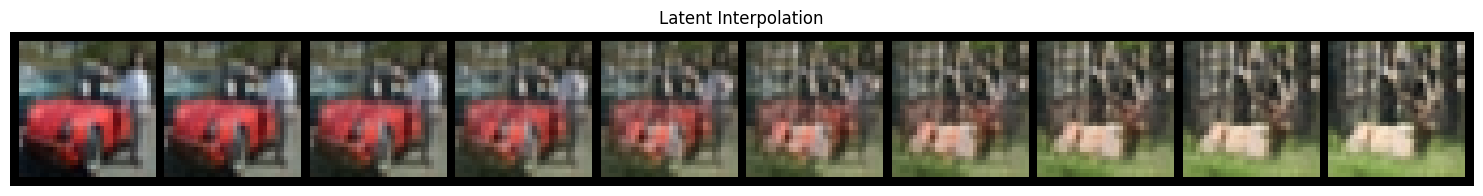

In [31]:
# Perform interpolation in the latent space
vae.eval()
samples, _ = datasampler_test.sample(2)
interpolated_samples = visualize_latent_interpolation(
    x1=samples[:1],
    x2=samples[1:2],
    vae=vae,
    n_steps=10,
    reverse_transform=cifar_reverse_transform,
)  # n_steps 3 h w

In [32]:
@torch.no_grad()
def estimate_latent_stats(vae, datasampler, batches=100, batch_size=256):
    zs = []
    vae.eval()
    for _ in range(batches):
        x, _ = datasampler.sample(batch_size)
        z_mean, _ = vae.encode(x)
        zs.append(z_mean)

    z = torch.cat(zs, dim=0)
    mean = z.mean(dim=(0, 2, 3), keepdim=True)
    std = z.std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
    return mean, std


latent_mean, latent_std = estimate_latent_stats(vae, datasampler)

### 6.2 Training a Latent Diffusion Model

In [ ]:
class LatentCFGTrainer(Trainer):
    def __init__(
        self,
        datasampler: DataSampler,
        vae: VAE,
        path: GaussianConditionalProbabilityPath,
        eta: float,
        null_label: int,
        eps: float = 0.001,
        latent_stats: tuple[float, float] = (0.0, 1.0),
        reverse_transform=None,
        **kwargs,
    ):
        assert eta > 0 and eta < 1
        super().__init__(**kwargs)
        self.datasampler = datasampler
        self.vae = vae
        self.path = path
        self.eta = eta
        self.eps = eps
        self.path = path
        self.null_label = null_label
        self.latent_mean, self.latent_std = latent_stats
        self.reverse_transform = reverse_transform

        self.vae.eval()
        for p in self.vae.parameters():
            p.requires_grad_(False)

    def load(self, model, run_name: str, resume_step: int):
        self.output_dir = os.path.join("runs/", run_name)

        self.model = model
        size_b = model_size_b(self.model)
        print(f"Loading model with size: {size_b / MiB:.3f} MiB")

        self.model.load_state_dict(
            torch.load(f"{self.output_dir}/step_{resume_step:06d}_model.pt")
        )
        self.model.eval()

        self.ema_model = copy.deepcopy(self.model)
        self.ema_model.load_state_dict(
            torch.load(f"{self.output_dir}/step_{resume_step:06d}_ema_model.pt")
        )
        self.ema_model.eval()

    def train(
        self,
        model: nn.Module,
        num_steps: int,
        lr: float = 1e-3,
        warmup_steps: int = 500,
        ckpt_every: Optional[int] = 500,
        run_name: Optional[str] = None,
        resume_step: int = 0,
        ema_decay: float = 0.999,
        **kwargs,
    ) -> Tuple[List[float], List[int]]:
        """
        Linear warmup from 0 -> lr over `warmup_steps`, then constant lr.
        """
        # Initialize run name and output directory
        run_name = run_name or self.random_name()
        self.output_dir = os.path.join("runs/", run_name)
        if resume_step != 0:
            os.makedirs(self.output_dir, exist_ok=False)
            print("Initialized output directory at: " + self.output_dir)

        # Grab size
        if resume_step != 0:
            self.load(model, run_name, resume_step)
        else:
            self.model = model
            self.ema_model = copy.deepcopy(self.model).eval()
            size_b = model_size_b(self.model)
            print(f"Training model with size: {size_b / MiB:.3f} MiB")

        # Initialize optimizer and LR
        self.opt = self.get_optimizer(lr)
        if resume_step != 0:
            opt_state = torch.load(f"{self.output_dir}/step_{resume_step:06d}_opt.pt")
            self.opt.load_state_dict(opt_state)

        self.model.train()

        for pg in self.opt.param_groups:
            pg["lr"] = 0.0

        # Main training loop
        losses: List[float] = []
        steps: List[int] = []

        pbar = tqdm(range(resume_step + 1, resume_step + num_steps + 1))
        for step in pbar:
            # Update LR
            if warmup_steps > 0 and step < warmup_steps:
                cur_lr = lr * float(step + 1) / float(warmup_steps)
            else:
                cur_lr = lr
            for pg in self.opt.param_groups:
                pg["lr"] = cur_lr

            # Forward + backward
            self.opt.zero_grad(set_to_none=True)
            loss = self.get_train_loss(**kwargs)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.opt.step()
            self.update_ema(decay=ema_decay)

            losses.append(float(loss.detach().item()))
            steps.append(step)

            pbar.set_description(
                f"Step {step}, lr={cur_lr:.2e}, loss={loss.item():.4f}"
            )

            # Callback if specified
            if ckpt_every is not None and step % ckpt_every == 0 and step > 0:
                self.model.eval()
                self.checkpoint(step, losses, steps)
                self.model.train()

        self.model.eval()
        return losses, steps

    @torch.no_grad()
    def update_ema(self, decay=0.999):
        for p, p_ema in zip(self.model.parameters(), self.ema_model.parameters()):
            p_ema.data.mul_(decay).add_(p.data, alpha=1 - decay)

        for b, b_ema in zip(self.model.buffers(), self.ema_model.buffers()):
            b_ema.copy_(b)

    @torch.no_grad()
    def visualize_samples(
        self,
        save_path: str = None,
        samples_per_class: int = 5,
        num_timesteps: int = 100,
        guidance_scales: List[float] = [1.0, 1.5, 2.0],
        use_tqdm=False,
        use_raw=False,
        title=None,
    ):
        # Graph
        fig, axes = plt.subplots(
            1, len(guidance_scales), figsize=(10 * len(guidance_scales), 10)
        )

        sample_model = self.model if use_raw else self.ema_model
        for idx, w in enumerate(guidance_scales):
            # Setup ode and simulator
            ode = CFGVectorFieldODE(self.model, guidance_scale=w, null_label=10)
            simulator = EulerSimulator(ode)

            # Sample initial conditions
            y = (
                torch.tensor(list(range(10)), dtype=torch.int64)
                .repeat_interleave(samples_per_class)
                .to(device)
            )
            num_samples = y.shape[0]
            z0 = self.path.p_simple.sample(num_samples)

            # Simulate
            ts = (
                torch.linspace(0, 0.999, num_timesteps)
                .view(1, -1, 1, 1, 1)
                .expand(num_samples, -1, 1, 1, 1)
                .to(device)
            )
            z1 = simulator.simulate(z0, ts, y=y, use_tqdm=use_tqdm)

            # Decode
            x1 = self.vae.decode(z1)

            # Plot
            v_min, v_max = x1.min(), x1.max()
            x1 = (x1 - v_min) / (v_max - v_min)
            grid = make_grid(
                x1, nrow=samples_per_class, normalize=True, value_range=(0, 1)
            )
            axes[idx].imshow(grid.permute(1, 2, 0).cpu())
            axes[idx].axis("off")
            axes[idx].set_title(f"Guidance: $w={w:.1f}$", fontsize=25)

        # Save
        if save_path is not None:
            plt.savefig(save_path)
            plt.close()
        else:
            plt.show()

    def checkpoint(self, step: int, losses: list[float], rng):
        # Save model
        torch.save(
            self.model.state_dict(),
            os.path.join(self.output_dir, f"step_{step:06d}_model.pt"),
        )
        torch.save(
            self.ema_model.state_dict(),
            os.path.join(self.output_dir, f"step_{step:06d}_ema_model.pt"),
        )
        torch.save(
            self.opt.state_dict(),
            os.path.join(self.output_dir, f"step_{step:06d}_opt.pt"),
        )

        plt.figure()
        plt.plot(list(rng), losses)
        plt.xlabel("Step")
        plt.ylabel("Loss")
        plt.title("Loss vs. Step")
        plt.savefig(os.path.join(self.output_dir, f"step_{step:06d}_loss.png"))
        plt.close()

        # Save output visualization
        self.visualize_samples(
            save_path=os.path.join(self.output_dir, f"step_{step:06d}_output.png"),
            title=f"Step {step}, loss={losses[-1]:.4f}",
        )

    def get_train_loss(self, batch_size: int) -> torch.Tensor:
        # Step 1: Sample z, y from data + encode
        with torch.no_grad():
            z, y = self.datasampler.sample(batch_size)
            z_mean, _ = self.vae.encode(z)
            z_enc = (z_mean - self.latent_mean) / self.latent_std

        # Step 2: Set each label to 10 (i.e., null) with probability eta
        mask = torch.rand(batch_size, device=y.device) < self.eta
        y = torch.where(mask, self.null_label, y)

        # Step 3: Sample t and x
        t = torch.rand(batch_size, device=z_enc.device) * (1 - self.eps)
        x = self.path.sample_conditional_path(z_enc, t)

        u_target = self.path.conditional_vector_field(x, z_enc, t)
        u_theta = self.model(x, t, y)

        return torch.nn.functional.mse_loss(u_theta, u_target)

In [46]:
# Finally, let's train!

vae = vae.to(device)

# Initialize latent probability path
c = 32
img_size = 8

path = GaussianConditionalProbabilityPath(
    p_data=None,
    p_simple_shape=[c, img_size, img_size],
    alpha=LinearAlpha(),
    beta=LinearBeta(),
).to(device)

# Initialize model
dit = DiffusionTransformerFlowModel(
    img_size=img_size,
    patch_size=1,
    num_layers=12,
    c=c,
    dim=384,
    heads=8,
    final_dim=64,
    n_classes=11,
).to(device)

# Initialize trainer
trainer = LatentCFGTrainer(
    datasampler=datasampler,
    vae=vae,
    path=path,
    eta=0.1,
    null_label=10,
    latent_stats=(latent_mean, latent_std),
    reverse_transform=cifar_reverse_transform,
)

In [47]:
# losses, steps = trainer.train(
#     model=dit,
#     num_steps=0,
#     lr=1e-4,
#     batch_size=256,
#     ckpt_every=10000,
#     run_name="dit",
#     warmup_steps=0,
#     resume_step=200000,
# )

# plt.plot(steps, losses)
# plt.xlabel("Step")
# plt.ylabel("Loss")
# plt.title("Loss vs. Step")
# plt.show()

In [48]:
trainer.load(dit, "dit", 220000)

Loading model with size: 124.624 MiB


  0%|          | 0/249 [00:00<?, ?it/s]

100%|██████████| 249/249 [00:40<00:00,  6.11it/s]


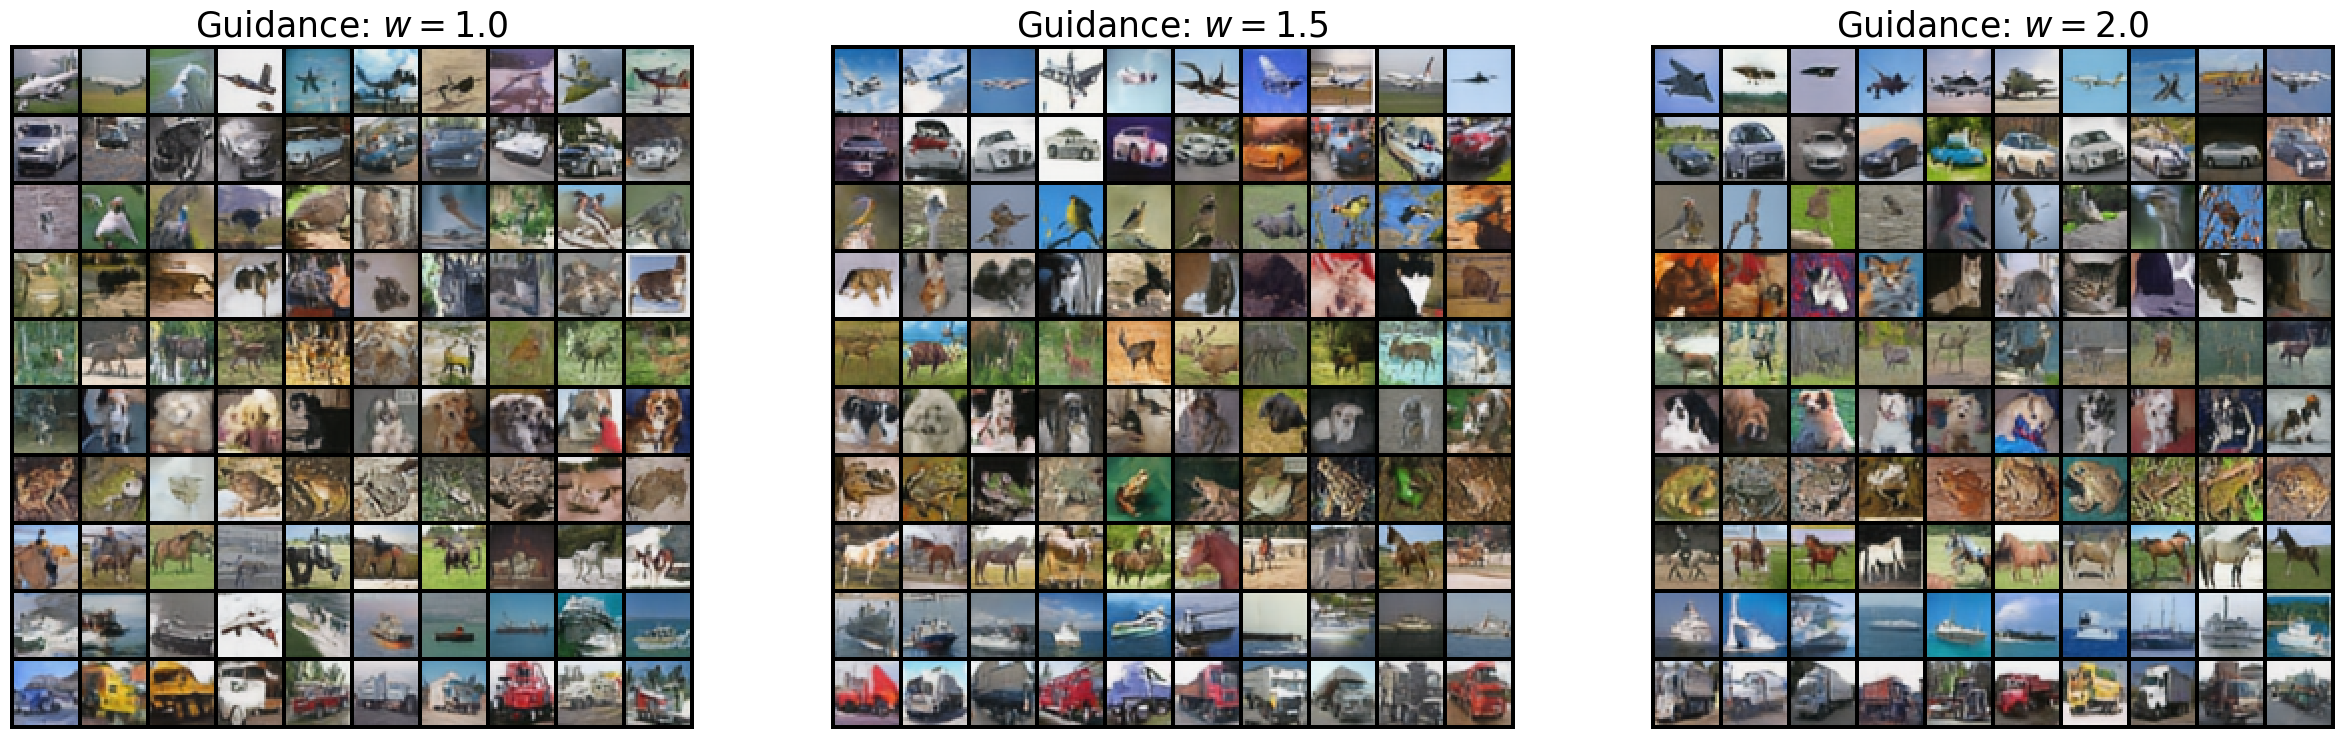

In [49]:
trainer.visualize_samples(use_tqdm=True, num_timesteps=250, samples_per_class=10)